In [1]:
packages <- c("ggplot2", "dplyr", "patchwork", "viridis", "platetools")
for (pkg in packages) {
  if (!require(pkg, character.only = TRUE)) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(pkg, character.only = TRUE)
        )
    )
  }
}
source("../../utils/r_themes.r")


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: patchwork

Loading required package: viridis

Warning message:
“package ‘viridis’ was built under R version 4.2.3”
Loading required package: viridisLite

Loading required package: platetools

Warning message:
“package ‘platetools’ was built under R version 4.2.3”


In [2]:
train_splits_df <- arrow::read_parquet("../data_splits/train.parquet")
test_splits_df <- arrow::read_parquet("../data_splits/test.parquet")
train_test_wells_df <- arrow::read_parquet("../data_splits/train_test_wells.parquet")

In [3]:
columns_to_keep <- c("Metadata_Well", "Metadata_dose")
train_splits_df <- train_splits_df %>% select(all_of(columns_to_keep))
test_splits_df <- test_splits_df %>% select(all_of(columns_to_keep))
# combine train and test splits for plotting
df <- rbind(
    train_splits_df,
    test_splits_df
)

df <- merge(
    df,
    train_test_wells_df,
)
# replace the "-" with ""
df$Metadata_Well <- gsub("-", "", df$Metadata_Well)
df$data_split <- gsub("train", "Train", df$data_split)
df$data_split <- gsub("test", "Test", df$data_split)
head(df)

,Metadata_Well,Metadata_dose,data_split
,<chr>,<dbl>,<chr>
1,C02,0.00,Train
2,C03,0.61,Train
3,C04,1.22,Test
4,C05,2.44,Train
5,C06,4.88,Train
6,C07,9.77,Train


In [4]:
train_test_split_platemap <- (
    raw_map(data = df$data_split,
        well = df$Metadata_Well,
        plate = 96)
    + theme_dark()
    # change the legend title
    + labs(fill = "Data Split")
)


Warning message:
“Warning: Your well label count ( 30 ) covers less than half the selected plate( 96 ).
Are you sure argument 'plate' is correct for the number of wells in your data?
note: Default is a 96-well plate.”


In [5]:
train_test_split_platemap_dose <- (
    raw_map(data = factor(df$Metadata_dose),
            well = df$Metadata_Well,
            plate = 96)
    + theme_dark()
    # use color palette for dose
    + scale_fill_manual(values = color_palette_dose)
    # set the legend title to "Dose"
    + labs(fill = "Staurosporine Dose (nM)")
    # make the legend two columns
    + guides(fill = guide_legend(ncol = 2))
)


Warning message:
“Warning: Your well label count ( 30 ) covers less than half the selected plate( 96 ).
Are you sure argument 'plate' is correct for the number of wells in your data?
note: Default is a 96-well plate.”


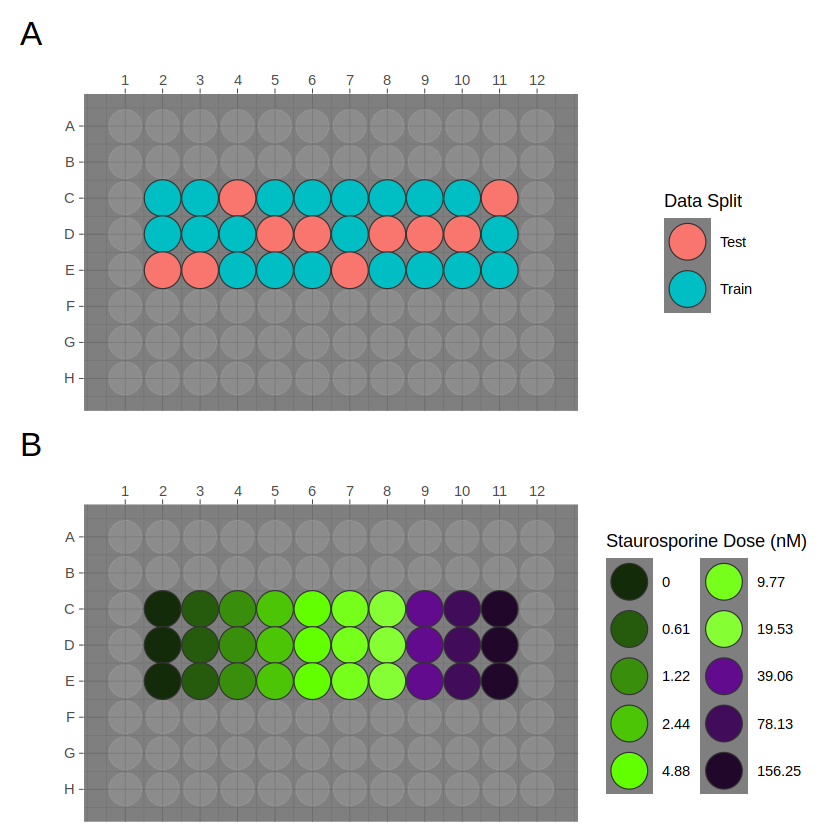

In [6]:
final_plot <- (
    train_test_split_platemap / train_test_split_platemap_dose  
    # + plot_layout(guides = "collect") 
    # add annotations for A and B and make them big
    + plot_annotation(tag_levels = "A") & theme(plot.tag = element_text(size = 20))
)
final_plot
ggsave("../figures/train_test_split_platemap.png", final_plot, width = 8, height = 10, dpi = 600)